# Day 0 — From One Model Call to One Graph Node

**Time:** 35–45 minutes  
**Build:** a one-node code explainer  
**New words:** model call, state, node, edge

You do not need to understand MLflow internals today. It is the shared doorway to the model. First get a response; then make the same input and output explicit as graph state.

## Checkpoint 1 — Get the first response

Before running: predict whether the model will identify the exact bug or only explain the code.

In [1]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    base_url="http://127.0.0.1:5001/gateway/mlflow/v1",
    api_key="not-needed",
    model="workshop-gemini",
)

reply = llm.invoke("Explain what an AI agent is in one sentence.")
print(reply.content)

An AI agent is an autonomous software system that perceives its environment, makes decisions, and takes actions to achieve specific goals.


## Checkpoint 2 — Meet the running example

The code below solves 0/1 knapsack, where each item may be used once. It looks valid but iterates capacity in the wrong direction. Today we only ask the model to explain it.

In [2]:
problem_statement = "Choose items within the capacity and maximize value. Each item may be selected at most once."
buggy_code = """n, capacity = map(int, input().split())
items = [tuple(map(int, input().split())) for _ in range(n)]
dp = [0] * (capacity + 1)
for weight, value in items:
    for current in range(weight, capacity + 1):
        dp[current] = max(dp[current], dp[current - weight] + value)
print(dp[capacity])"""

prompt = f"Problem:\n{problem_statement}\n\nCode:\n{buggy_code}\n\nExplain what the code is trying to do."
print(llm.invoke(prompt).content)

Here is a detailed explanation of what the code is doing, along with an **important caveat** regarding a bug in the code compared to your problem description.

---

### High-Level Summary
The code uses **Dynamic Programming** to solve a variation of the **Knapsack Problem**. It aims to find the maximum value you can achieve given a set of items (each with a specific weight and value) without exceeding a given total weight `capacity`.

---

### Line-by-Line Breakdown

1. **`n, capacity = map(int, input().split())`**
   * Reads two integers from the input: 
     * `n`: The number of available items.
     * `capacity`: The maximum weight the knapsack can hold.

2. **`items = [tuple(map(int, input().split())) for _ in range(n)]`**
   * Reads `n` lines of input. Each line contains a pair of integers representing an item's `(weight, value)`. 
   * Stores these pairs as a list of tuples.

3. **`dp = [0] * (capacity + 1)`**
   * Initializes a 1D array (list) of size `capacity + 1` filled with 

## Checkpoint 3 — Predict the graph

The graph will have one application node. Predict its state before running:

| Field | Present at start? | Updated by the node? |
| --- | --- | --- |
| `problem` | Yes | No |
| `code` | Yes | No |
| `explanation` | No | Yes |

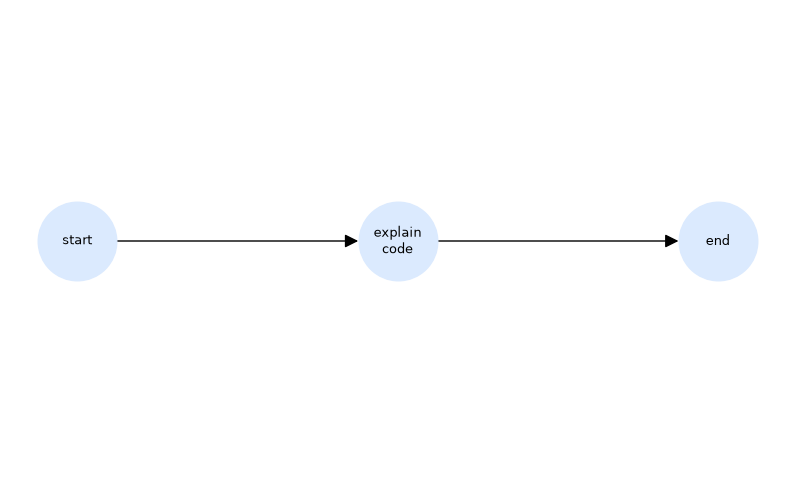

In [3]:
from typing import TypedDict
from langgraph.graph import END, START, StateGraph
import sys
sys.path.append("../..")
from graph_image import show_graph

class State(TypedDict, total=False):
    problem: str
    code: str
    explanation: str

def explain_code(state: State):
    prompt = f"Problem:\n{state['problem']}\n\nCode:\n{state['code']}\n\nExplain the algorithm and identify anything suspicious."
    return {"explanation": llm.invoke(prompt).content}

builder = StateGraph(State)
builder.add_node("explain_code", explain_code)
builder.add_edge(START, "explain_code")
builder.add_edge("explain_code", END)
graph = builder.compile()
show_graph(graph)

## Checkpoint 4 — Run and inspect state

The test cell calls the graph, not the model. The returned explanation is read from state.

In [4]:
result = graph.invoke({"problem": problem_statement, "code": buggy_code})
assert result["problem"] == problem_statement
assert result["code"] == buggy_code
assert result["explanation"].strip()
print(result["explanation"])

### Algorithm Explanation

The code attempts to solve the **Knapsack Problem** using **Dynamic Programming (DP)** with a 1D array to save space.

1. **State Definition:** 
   `dp[w]` represents the maximum total value achievable with a knapsack capacity of `w`.

2. **Initialization:** 
   An array `dp` of size `capacity + 1` is initialized to all zeros, representing that a knapsack with 0 capacity (or no items selected) yields 0 value.

3. **State Transition:** 
   For each item with weight `weight` and value `value`, the algorithm updates the DP table:
   $$\text{dp}[\text{current}] = \max(\text{dp}[\text{current}], \text{dp}[\text{current} - \text{weight}] + \text{value})$$
   This means for a knapsack of capacity `current`, we choose the maximum between:
   * **Not taking the item:** Keeping the previous maximum value (`dp[current]`).
   * **Taking the item:** Adding `value` to the maximum value achievable with the remaining capacity (`dp[current - weight] + value`).

---

### What 

## Intentional failure — Break the state contract

Remove `code` from the input in a copy of the test cell. The node fails because its state contract requires both fields. Restore it before continuing.

**Exit question:** What did the graph add that the direct model call did not?